<a href="https://colab.research.google.com/github/ManishSahani24/Quantum-Information-and-Computing/blob/main/Shors_Algoriyhm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Shor's Algorithm:

## 1. Introduction
Shor's Algorithm, developed by Peter Shor in 1994, is a milestone in quantum computing. It solves the integer factorization problem in polynomial time, offering an exponential speedup over the best-known classical algorithms (like the General Number Field Sieve). Because modern cryptographic systems (such as RSA) rely on the classical difficulty of factoring large numbers, Shor's algorithm theoretically compromises these systems.


## 2. Mathematical Foundations

Shor's algorithm cleverly reduces the problem of factoring to **period finding**, which a quantum computer can solve efficiently.

### 2.1 The Classical Reduction
Given a composite number $N$ (the number we want to factor):
1. Pick a random integer $a$ such that $1 < a < N$.
2. Compute the greatest common divisor $\text{gcd}(a, N)$. If it is not $1$, we are done—we have found a non-trivial factor!
3. If $\text{gcd}(a, N) = 1$, we define the modular exponentiation function:
   $$f(x) = a^x \pmod N$$
4. We need to find the **period** $r$ of this function. The period is the smallest positive integer $r$ such that:
   $$a^r \equiv 1 \pmod N$$
5. If $r$ is odd, or if $a^{r/2} \equiv -1 \pmod N$, the choice of $a$ failed. We must pick a new $a$ and try again.
6. If $r$ is even and $a^{r/2} \not\equiv -1 \pmod N$, then the factors of $N$ are:
   $$p = \text{gcd}(a^{r/2} + 1, N) \quad \text{and} \quad q = \text{gcd}(a^{r/2} - 1, N)$$


The hard thing in the classical algorithm is finding the period $r$. Shor's algorithm uses a quantum computer to find $r$ efficiently through **Quantum Phase Estimation (QPE)**.

1. **State Preparation**: We initialize two quantum registers. The first (counting register) is placed in a superposition of all possible states using Hadamard gates. The second (target register) is initialized to $|1\rangle$.
2. **Modular Exponentiation**: We apply a series of controlled unitary operations $U$ to the target register, where $U|y\rangle = |a y \pmod N\rangle$. This entangles the counting register with the target register.
3. **Inverse Quantum Fourier Transform (IQFT)**: Applying the IQFT to the counting register extracts the phase information associated with the period $r$.
4. **Measurement**: We measure the counting register. The measured decimal value $C$ relates to the phase by $\frac{C}{2^n} \approx \frac{s}{r}$, where $s$ is a random integer. We use the **Continued Fractions Algorithm** to extract $r$.

In [2]:
!pip install -q qiskit
!pip install -q qiskit_ibm_runtime
!pip install -q qiskit_aer
!pip install -q matplotlib numpy pylatexenc -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.0 MB/s eta 0:00:00


In [3]:

import numpy as np
import matplotlib.pyplot as plt
from math import gcd
from fractions import Fraction


from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

## 3.Implementation: Factoring 15

We will implement the algorithm to factor $N = 15$. We need to choose a co-prime base $a$. Let's pick $a = 7$.
Our goal is to find the period of $f(x) = 7^x \pmod{15}$.

### 3.1 Constructing the Modular Exponentiation Circuit
In a generalized Shor's algorithm, building the $U|y\rangle = |a y \pmod N\rangle$ gate dynamically for large numbers is complex. For educational purposes, it is standard practice to construct a specific optimized circuit for $N=15$ and our chosen $a$.

In [35]:
def c_amod15(a, power):

    if a not in [2, 4, 7, 8, 11, 13]:
        raise ValueError("'a' must be 2, 4, 7, 8, 11 or 13")

    U = QuantumCircuit(4)
    for _ in range(power):
        if a in [2, 13]:
            U.swap(2, 3)
            U.swap(1, 2)
            U.swap(0, 1)
        if a in [7, 8]:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
        if a in [4, 11]:
            U.swap(1, 3)
            U.swap(0, 2)
        if a in [7, 11, 13]:
            for q in range(4):
                U.x(q)

    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    c_U = U.control()
    return c_U

### 3.2 The Inverse Quantum Fourier Transform (IQFT)
To extract the phase information, we need to apply the Inverse QFT to our counting register. The IQFT maps the frequency domain back to the computational basis.

In [36]:
def qft_dagger(n):
    qc = QuantumCircuit(n)

    # Swap qubits
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)

    for j in range(n):
        for m in range(j):
            # Applying controlled-phase gates with negative angles
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.h(j)

    qc.name = "IQFT"
    return qc

### 3.3 Assembling the Full Quantum Circuit
We will use $n_{count} = 4$ counting qubits. The target register requires 4 qubits to represent numbers up to 15.

In [42]:
import matplotlib.pyplot as plt
N = 15
a = 7
n_count = 4

#(4 counting qubits, 4 target qubits, 4 classical bits for measurement)
qc = QuantumCircuit(n_count + 4, n_count)


for q in range(n_count):
    qc.h(q)

# Initialize the target register to |1> (computational basis state 0001)
qc.x(n_count) # The lowest qubit of the target register is at index n_count

# Applying controlled modular exponentiation operations
for q in range(n_count):
    # append the c_U gate controlled by qubit q, acting on the target register
    target_qubits = [i + n_count for i in range(4)]
    qc.append(c_amod15(a, 2**q), [q] + target_qubits)

# Step 4: Apply the Inverse QFT to the counting register
qc.append(qft_dagger(n_count), range(n_count))

# Step 5: Measure the counting register
qc.measure(range(n_count), range(n_count))

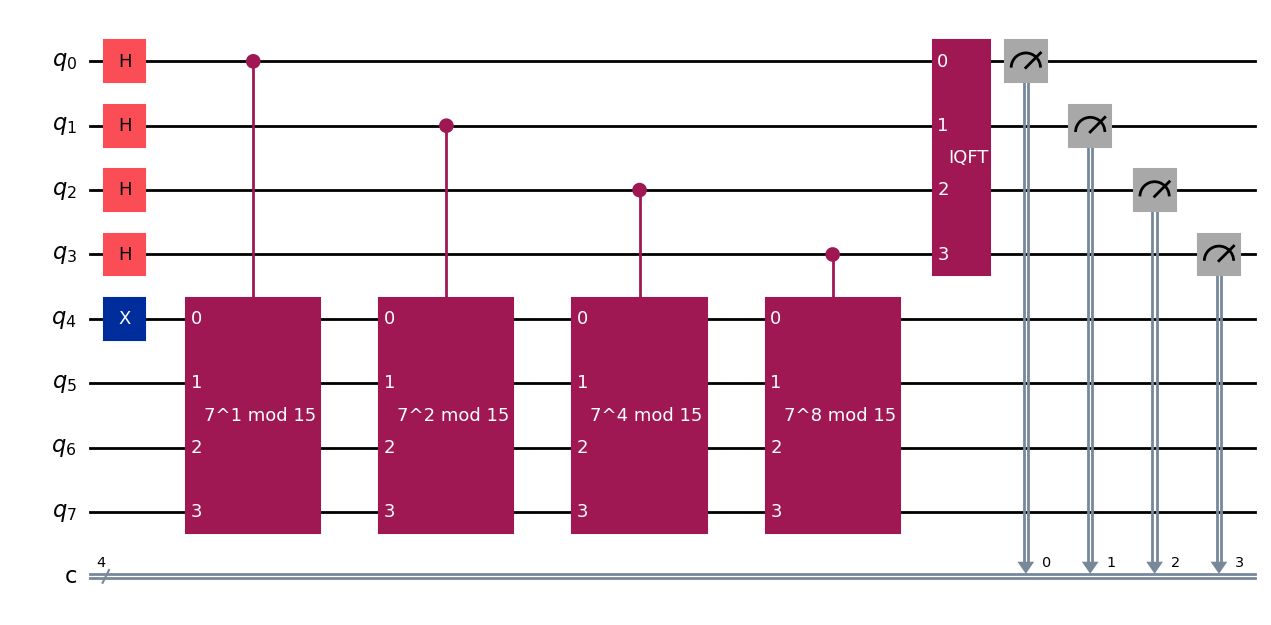

In [43]:
!pip install -q pylatexenc
import qiskit.visualization
qc.draw('mpl')

## 4. Simulation
Let's run our circuit on a quantum simulator to get our measurement outcomes. We will then process these outcomes to find the period $r$ and, ultimately, the factors of $15$.

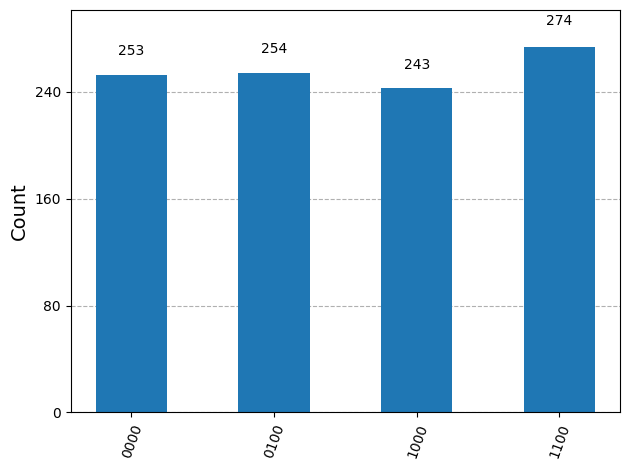

In [44]:

simulator = AerSimulator()

#decomposing
qc_decomposed = qc.decompose()
result = simulator.run(qc_decomposed, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)

The histogram shows the probabilities of measuring various states. The measured binary strings represent our phase estimations. We must convert these to decimal, calculate the phase, and use the continued fractions algorithm to find $r$.

In [45]:
measured_phases = []

print(f"Algorithm parameters: N = {N}, a = {a}\n")

for output in counts:
    # Convert binary output to decimal
    decimal_val = int(output, 2)

    # Calculate phase = decimal_val / 2^(n_count)
    phase = decimal_val / (2**n_count)
    measured_phases.append(phase)

    # Use Fraction to find the closest fraction (s/r) with a denominator < N
    frac = Fraction(phase).limit_denominator(15)
    r = frac.denominator

    print(f"Measured Binary: {output} | Decimal: {decimal_val} | Phase: {phase} | Estimated Period (r): {r}")

    # If r is odd or a^(r/2) is -1 mod N, it's a trivial case. Otherwise, we calculate the factors.
    if r % 2 == 0:
        guess_1 = gcd(a**(r//2) - 1, N)
        guess_2 = gcd(a**(r//2) + 1, N)


        if guess_1 not in [1, N] and guess_2 not in [1, N]:
            print(f"Non-trivial factors found: {guess_1} and {guess_2}")
        else:
            print(" Try a different measurement or 'a'.")
    else:
        print("Period is odd. Invalid for factoring.")

Algorithm parameters: N = 15, a = 7

Measured Binary: 0000 | Decimal: 0 | Phase: 0.0 | Estimated Period (r): 1
Period is odd. Invalid for factoring.
Measured Binary: 0100 | Decimal: 4 | Phase: 0.25 | Estimated Period (r): 4
Non-trivial factors found: 3 and 5
Measured Binary: 1000 | Decimal: 8 | Phase: 0.5 | Estimated Period (r): 2
 Try a different measurement or 'a'.
Measured Binary: 1100 | Decimal: 12 | Phase: 0.75 | Estimated Period (r): 4
Non-trivial factors found: 3 and 5


## 5. Conclusion
By utilizing quantum superposition and entanglement, followed by the Inverse Quantum Fourier transform, we extracted the period of the modular exponentiation function. Classical post-processing of this period easily yielded the prime factors of 15 (which are 3 and 5).

While factoring 15 is trivial for a classical computer, this very logic mathematically holds true for large numbers—the only barrier is engineering quantum hardware with enough stable, error-corrected qubits to scale the registers.

* Shor's algorithm does not output the complete list of prime factors all at once. Instead, the algorithm is designed to find one non-trivial factor pair of a composite number $N$.

